In [ ]:
# Run this cell to mount your Google Drive.
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Installing necessary packages
!pip install lifelines scikit-survival

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.7/115.7 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 298.3/298.3 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.1/220.1 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.0 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=02e97073168c5f8b3b506515294f5d46690d0ccd45c9befe5be89fe9f285968b
  Stored in directory: /root/.cache/pip/wheels/8b/67/f4/2caaae2146198dcb824f31a303833b07b14a5ec863fb3acd7b
Successfully built autograd-gamma
  Attempting uninstall: osqp
    Found existing installation: osqp 1.0.1
    Uninstalling osqp-1.

In [ ]:
df1 = pd.read_csv("../data/preprocessed/New_df.csv") # Change file path as per your directory structure
df2 = pd.read_csv("../data/preprocessed/df_with_pc.csv") # Change file path as per your directory structure

In [ ]:
pc_cols = ["PC1", "PC2", "PC3"]
df_pc = df2[pc_cols]

df = pd.concat([df1, df_pc], axis=1)

In [ ]:
df.head()

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,transf_Age,PC1,PC2,PC3
0,15674932,668,1,2,33,1095,2,1,0,181449.97,0,2.345499,-1.222383,-0.045501,0.301590
1,15749177,627,1,2,33,365,2,1,1,49503.50,0,2.345499,-1.167725,-0.543733,0.197915
2,15694510,678,1,2,40,3650,2,1,0,184866.69,0,2.425028,-0.660072,0.122461,0.435229
3,15741417,581,1,2,34,730,1,1,1,84560.88,0,2.358088,0.087482,-1.171597,0.995843
4,15766172,716,3,2,33,1825,2,1,1,15068.83,0,2.345499,-1.286373,0.537796,0.422965


# **1. Kaplan-Meier Estimator (KM)**

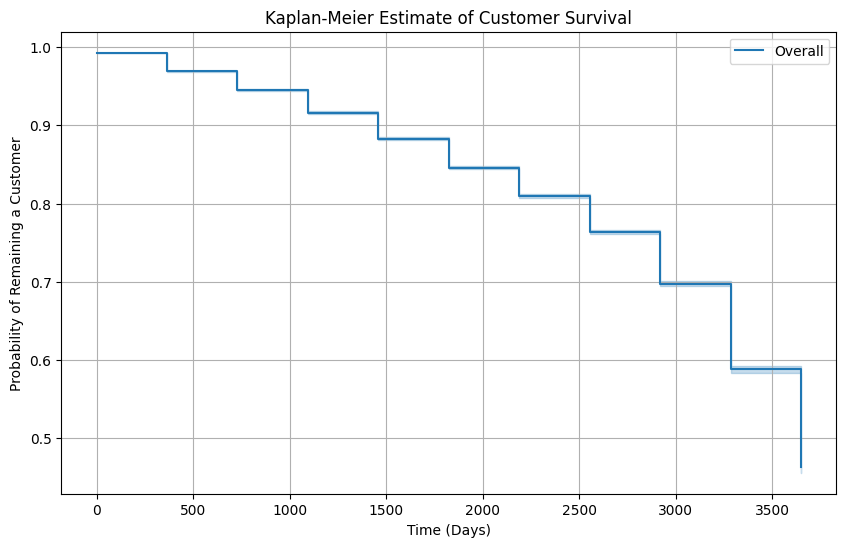

In [ ]:
from lifelines import KaplanMeierFitter

T = df['Tenure']  # Time
E = df['Exited']  # Event indicator (1 = churned, 0 = still active)

# Fit the KM model
kmf = KaplanMeierFitter()
kmf.fit(T, event_observed=E, label='Overall')

# Plot the survival curve
plt.figure(figsize=(10, 6))
kmf.plot_survival_function()
plt.title('Kaplan-Meier Estimate of Customer Survival')
plt.xlabel('Time (Days)')
plt.ylabel('Probability of Remaining a Customer')
plt.grid(True)
plt.show()

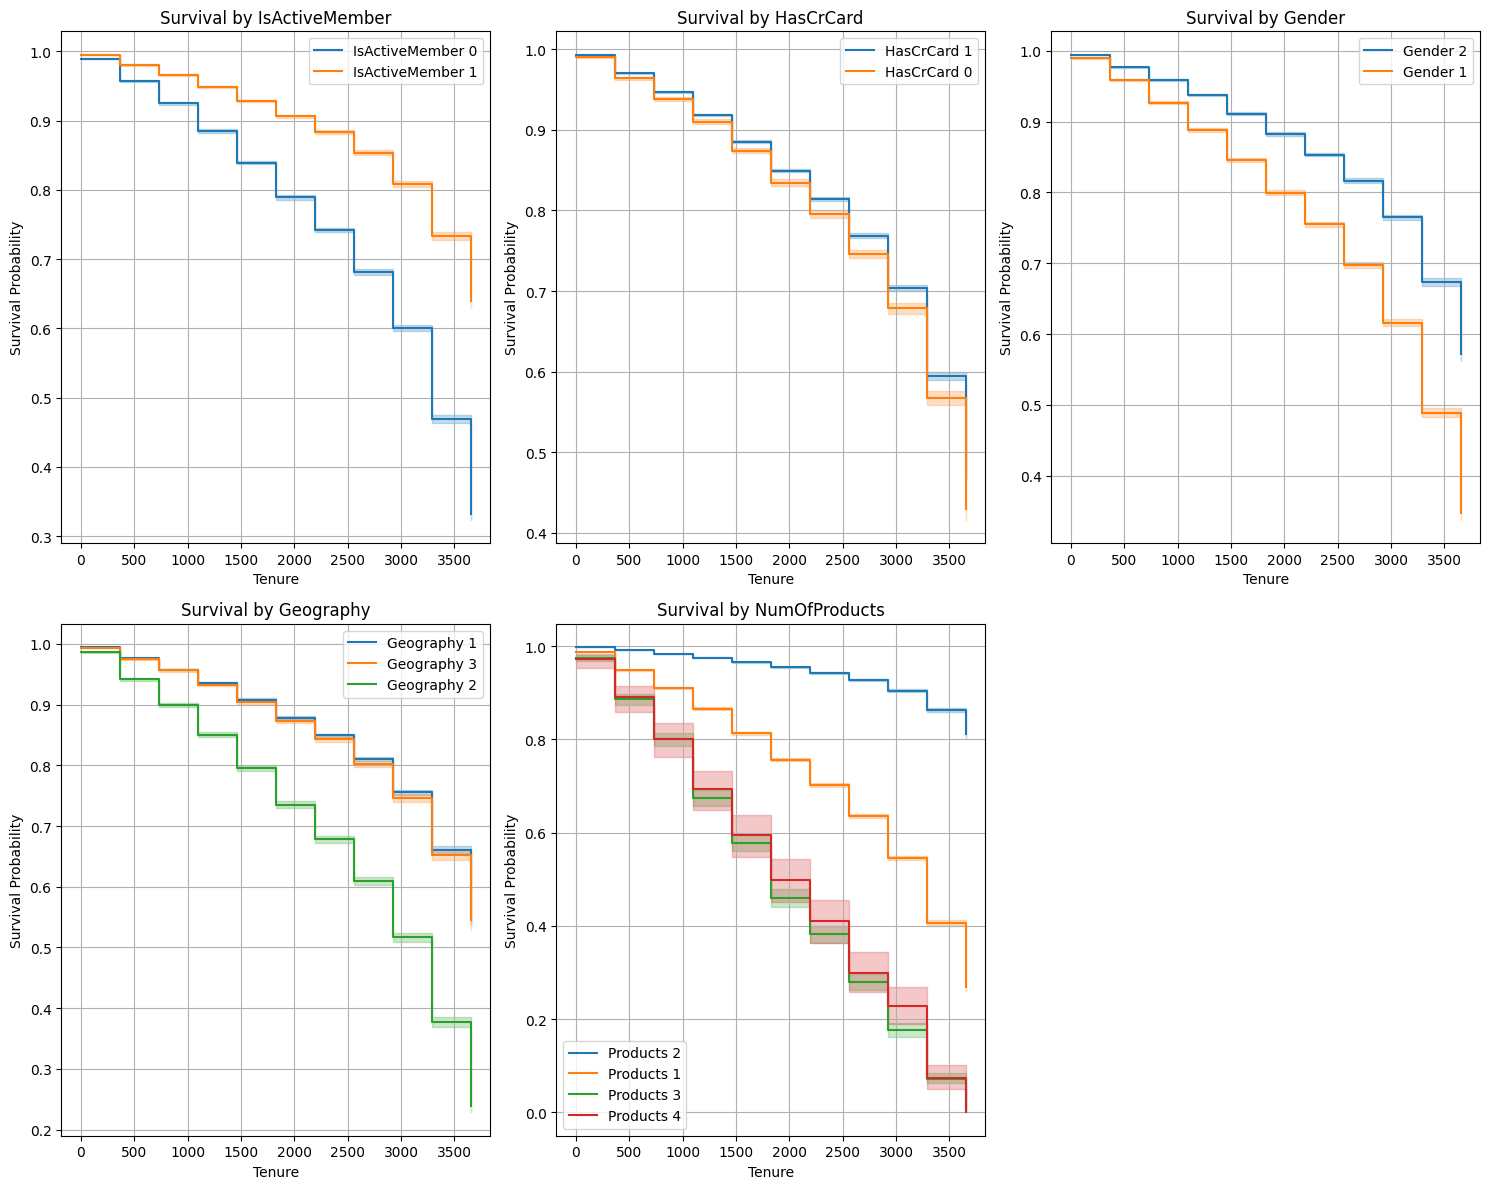

In [ ]:
# Assuming your data is in a DataFrame called 'df'

categorical_cols = ['IsActiveMember', 'HasCrCard', 'Gender', 'Geography', 'NumOfProducts']

plt.figure(figsize=(15, 12))  # Adjust figure size for a 2x3 grid (5 plots + 1 empty)

for i, col in enumerate(categorical_cols):
    plt.subplot(2, 3, i + 1)  # Create subplots in a 2x3 grid

    for category in df[col].unique():
        subset = df[df[col] == category]
        T = subset['Tenure']  # or your time variable
        E = subset['Exited']  # or your event variable

        kmf = KaplanMeierFitter()
        if col == 'Gender':
          label = f'Gender {category}'
        elif col == 'Geography':
          label = f'Geography {category}'
        elif col == 'NumOfProducts':
          label = f'Products {category}'
        else:
          label = f'{col} {category}'
        kmf.fit(T, event_observed=E, label=label)
        kmf.plot_survival_function(ax=plt.gca())

    plt.title(f'Survival by {col}')
    plt.xlabel('Tenure')  # Adjust as needed
    plt.ylabel('Survival Probability')
    plt.grid(True)

plt.tight_layout()  # Improve spacing between plots
plt.show()

# **2. Log-Rank Test**

In [ ]:
from lifelines.statistics import logrank_test

# 1. Survival by IsActiveMember
active = df[df['IsActiveMember'] == 1]
inactive = df[df['IsActiveMember'] == 0]
results_active = logrank_test(active['Tenure'], inactive['Tenure'],
                             active['Exited'], inactive['Exited'], alpha=0.05)
print("IsActiveMember Log-Rank Test:")
print(results_active)
if results_active.p_value < 0.05:
    print("The survival curves are significantly different.")
else:
    print("The survival curves are not significantly different.")

IsActiveMember Log-Rank Test:
<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
             alpha = 0.05
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
        5961.96 <0.005       inf
The survival curves are significantly different.


In [ ]:
# 2. Survival by HasCrCard
has_card = df[df['HasCrCard'] == 1]
no_card = df[df['HasCrCard'] == 0]
results_card = logrank_test(has_card['Tenure'], no_card['Tenure'],
                           has_card['Exited'], no_card['Exited'], alpha=0.05)
print("\nHasCrCard Log-Rank Test:")
print(results_card)
if results_card.p_value < 0.05:
    print("The survival curves are significantly different.")
else:
    print("The survival curves are not significantly different.")


HasCrCard Log-Rank Test:
<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
             alpha = 0.05
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
          74.59 <0.005     57.26
The survival curves are significantly different.


In [ ]:
from lifelines.statistics import logrank_test
# 3. Survival by Gender (assuming Gender 1 and Gender 2 exist as columns)
gender1 = df[df['Gender'] == 1]  # Assuming 1 represents one gender
gender2 = df[df['Gender'] == 2]  # Assuming 2 represents the other gender
results_gender = logrank_test(gender1['Tenure'], gender2['Tenure'],
                             gender1['Exited'], gender2['Exited'], alpha=0.05)
print("\nGender Log-Rank Test:")
print(results_gender)
if results_gender.p_value < 0.05:
    print("The survival curves are significantly different.")
else:
    print("The survival curves are not significantly different.")


Gender Log-Rank Test:
<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
             alpha = 0.05
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
        3084.38 <0.005       inf
The survival curves are significantly different.


In [ ]:
# 4. Survival by Geography (pairwise comparisons)
geo1 = df[df['Geography'] == 1] # Changed from '1' to 1
geo2 = df[df['Geography'] == 2] # Changed from '2' to 2
geo3 = df[df['Geography'] == 3] # Changed from '3' to 3

# Geography 1 vs Geography 2
results_geo1_2 = logrank_test(geo1['Tenure'], geo2['Tenure'],
                                geo1['Exited'], geo2['Exited'], alpha=0.05)
print("\nGeography (1 vs 2) Log-Rank Test:")
print(results_geo1_2)
if results_geo1_2.p_value < 0.05:
    print("The survival curves are significantly different.")
else:
    print("The survival curves are not significantly different.")

# Geography 1 vs Geography 3
results_geo1_3 = logrank_test(geo1['Tenure'], geo3['Tenure'],
                                geo1['Exited'], geo3['Exited'], alpha=0.05)
print("\nGeography (1 vs 3) Log-Rank Test:")
print(results_geo1_3)
if results_geo1_3.p_value < 0.05:
    print("The survival curves are significantly different.")
else:
    print("The survival curves are not significantly different.")

# Geography 2 vs Geography 3
results_geo2_3 = logrank_test(geo2['Tenure'], geo3['Tenure'],
                                geo2['Exited'], geo3['Exited'], alpha=0.05)
print("\nGeography (2 vs 3) Log-Rank Test:")
print(results_geo2_3)
if results_geo2_3.p_value < 0.05:
    print("The survival curves are significantly different.")
else:
    print("The survival curves are not significantly different.")


Geography (1 vs 2) Log-Rank Test:
<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
             alpha = 0.05
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
        5548.56 <0.005       inf
The survival curves are significantly different.

Geography (1 vs 3) Log-Rank Test:
<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
             alpha = 0.05
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           6.14 0.01      6.24
The survival curves are significantly different.

Geography (2 vs 3) Log-Rank Test:
<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
             alpha = 0.05
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
        3038.24 <0.005       inf
The survival curves are significantl

In [ ]:
# 5. Survival by NumOfProducts
# Products 1 vs Products 2
prod1 = df[df['NumOfProducts'] == 1]
prod2 = df[df['NumOfProducts'] == 2]
results_prod1_2 = logrank_test(prod1['Tenure'], prod2['Tenure'],
                                 prod1['Exited'], prod2['Exited'], alpha=0.05)
print("\nNumOfProducts (Prod1 vs Prod2) Log-Rank Test:")
print(results_prod1_2)
if results_prod1_2.p_value < 0.05:
    print("The survival curves are significantly different.")
else:
    print("The survival curves are not significantly different.")

# Products 1 vs Products 3
prod3 = df[df['NumOfProducts'] == 3]
results_prod1_3 = logrank_test(prod1['Tenure'], prod3['Tenure'],
                                 prod1['Exited'], prod3['Exited'], alpha=0.05)
print("\nNumOfProducts (Prod1 vs Prod3) Log-Rank Test:")
print(results_prod1_3)
if results_prod1_3.p_value < 0.05:
    print("The survival curves are significantly different.")
else:
    print("The survival curves are not significantly different.")

# Products 1 vs Products 4
prod4 = df[df['NumOfProducts'] == 4]
results_prod1_4 = logrank_test(prod1['Tenure'], prod4['Tenure'],
                                 prod1['Exited'], prod4['Exited'], alpha=0.05)
print("\nNumOfProducts (Prod1 vs Prod4) Log-Rank Test:")
print(results_prod1_4)
if results_prod1_4.p_value < 0.05:
    print("The survival curves are significantly different.")
else:
    print("The survival curves are not significantly different.")

# Products 2 vs Products 3
results_prod2_3 = logrank_test(prod2['Tenure'], prod3['Tenure'],
                                 prod2['Exited'], prod3['Exited'], alpha=0.05)
print("\nNumOfProducts (Prod2 vs Prod3) Log-Rank Test:")
print(results_prod2_3)
if results_prod2_3.p_value < 0.05:
    print("The survival curves are significantly different.")
else:
    print("The survival curves are not significantly different.")

# Products 2 vs Products 4
results_prod2_4 = logrank_test(prod2['Tenure'], prod4['Tenure'],
                                 prod2['Exited'], prod4['Exited'], alpha=0.05)
print("\nNumOfProducts (Prod2 vs Prod4) Log-Rank Test:")
print(results_prod2_4)
if results_prod2_4.p_value < 0.05:
    print("The survival curves are significantly different.")
else:
    print("The survival curves are not significantly different.")

# Products 3 vs Products 4
results_prod3_4 = logrank_test(prod3['Tenure'], prod4['Tenure'],
                                 prod3['Exited'], prod4['Exited'], alpha=0.05)
print("\nNumOfProducts (Prod3 vs Prod4) Log-Rank Test:")
print(results_prod3_4)
if results_prod3_4.p_value < 0.05:
    print("The survival curves are significantly different.")
else:
    print("The survival curves are not significantly different.")


NumOfProducts (Prod1 vs Prod2) Log-Rank Test:
<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
             alpha = 0.05
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
       17895.05 <0.005       inf
The survival curves are significantly different.

NumOfProducts (Prod1 vs Prod3) Log-Rank Test:
<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
             alpha = 0.05
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
        2504.62 <0.005       inf
The survival curves are significantly different.

NumOfProducts (Prod1 vs Prod4) Log-Rank Test:
<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
             alpha = 0.05
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
         382.41 <0.005    280